In [13]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

pip install pandas scikit-learn matplotlib

In [14]:
iris = load_iris()

X = iris.data
y = iris.target

target_names = iris.target_names

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

KNN crestion and Training

In [16]:
knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [17]:
y_pred = knn.predict(X_test)

Prediction Data Frame

In [18]:
prediction_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

In [19]:
prediction_df['Actual Flower'] = prediction_df['Actual'].apply(
    lambda x: target_names[x]
)

prediction_df['Predicted Flower'] = prediction_df['Predicted'].apply(
    lambda x: target_names[x]
)

In [20]:
prediction_df['Result'] = prediction_df.apply(
    lambda row: 'Correct'
    if row['Actual'] == row['Predicted']
    else 'Wrong',
    axis=1
)

In [21]:
print("\n========== PREDICTIONS ==========\n")

print(prediction_df[
    ['Actual Flower',
     'Predicted Flower',
     'Result']
].head(10))


========== PREDICTIONS ==========

  Actual Flower Predicted Flower   Result
0    versicolor       versicolor  Correct
1        setosa           setosa  Correct
2     virginica        virginica  Correct
3    versicolor       versicolor  Correct
4    versicolor       versicolor  Correct
5        setosa           setosa  Correct
6    versicolor       versicolor  Correct
7     virginica        virginica  Correct
8    versicolor       versicolor  Correct
9    versicolor       versicolor  Correct


In [22]:
correct_predictions = prediction_df[
    prediction_df['Result'] == 'Correct'
]

print("\n========== CORRECT PREDICTIONS ==========\n")

print(correct_predictions[
    ['Actual Flower',
     'Predicted Flower']
])


========== CORRECT PREDICTIONS ==========

   Actual Flower Predicted Flower
0     versicolor       versicolor
1         setosa           setosa
2      virginica        virginica
3     versicolor       versicolor
4     versicolor       versicolor
5         setosa           setosa
6     versicolor       versicolor
7      virginica        virginica
8     versicolor       versicolor
9     versicolor       versicolor
10     virginica        virginica
11        setosa           setosa
12        setosa           setosa
13        setosa           setosa
14        setosa           setosa
15    versicolor       versicolor
16     virginica        virginica
17    versicolor       versicolor
18    versicolor       versicolor
19     virginica        virginica
20        setosa           setosa
21     virginica        virginica
22        setosa           setosa
23     virginica        virginica
24     virginica        virginica
25     virginica        virginica
26     virginica        virginica
27  

In [23]:
wrong_predictions = prediction_df[
    prediction_df['Result'] == 'Wrong'
]

print("\n========== WRONG PREDICTIONS ==========\n")

print(wrong_predictions[
    ['Actual Flower',
     'Predicted Flower']
])


========== WRONG PREDICTIONS ==========

Empty DataFrame
Columns: [Actual Flower, Predicted Flower]
Index: []


In [24]:
accuracy = accuracy_score(y_test, y_pred)

print("\n===================================")
print("Model Accuracy :", accuracy * 100, "%")
print("===================================")


Model Accuracy : 100.0 %


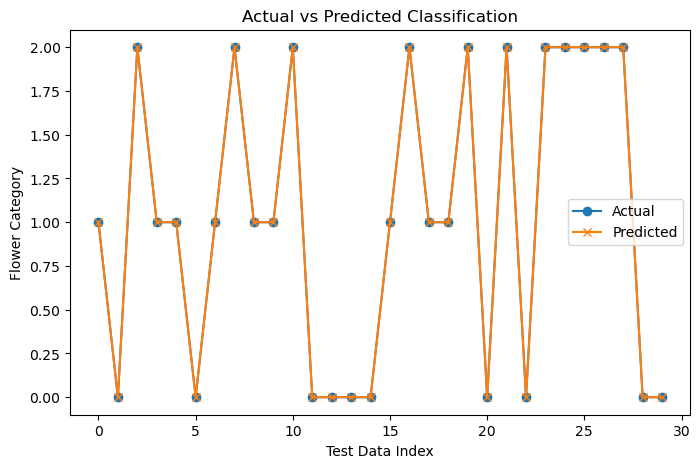

In [25]:
# ==========================================
# Plot Graph
# ==========================================

plt.figure(figsize=(8,5))

plt.plot(y_test, label='Actual', marker='o')

plt.plot(y_pred, label='Predicted', marker='x')

plt.xlabel("Test Data Index")

plt.ylabel("Flower Category")

plt.title("Actual vs Predicted Classification")

plt.legend()

plt.show()